# Data Analysis of Predictive Maintenance Dataset

## Research Question and Hypothesis

**Research Question:**
Can remaining useful life (RUL) or failure within 24 hours be predicted based on machine sensor data?

**Hypothesis:**
If sensor data varies significantly from the standard operating range, then the RUL will decrease and the machine will fail within 24 hours.

## Dataset

The Industrial Machine Predictive Maintenance dataset is a synthetic IoT dataset sourced from Kaggle ([Industrial Machine Predictive Maintenance](https://www.kaggle.com/datasets/tatheerabbas/industrial-machine-predictive-maintenance?resource=download)). 

**Dataset Details:**
- **Size:** 24,042 records across 20 machines
- **Time Period:** January 1-14, 2024
- **Source:** Synthetic CNC and industrial machine sensor data
- **Purpose:** Designed for predictive maintenance, failure forecasting, and RUL (Remaining Useful Life) estimation

**Features:**
- **Sensor measurements:** vibration_rms, temperature_motor, current_phase_avg, pressure_level, rpm, ambient_temp, hours_since_maintenance
- **Machine metadata:** machine_id, machine_type, operating_mode
- **Target variables:** failure_within_24h (binary), rul_hours (continuous), failure_type

**Why this dataset:** The dataset captures real-world maintenance scenarios where machines exhibit degradation patterns over time. Understanding these patterns through sensor data can enable predictive maintenance strategies, reducing downtime and costs.

More details can be found in the [dataset card](./dataset_card.md).

## Data Preprocessing

**Missing Data Handling:**
- Converted `timestamp` to datetime and seconds for time-based processing
- Filled missing sensor values with interpolation within each machine over time
- Applied forward and backward fill to cover edge cases after interpolation

**Feature Engineering:**
- Created delta-per-second features for each sensor to capture change over time
- Used `timestamp_seconds` for chronological ordering and time-difference calculations

**Train/Test Split and Scaling:**
- Split the dataset into train/test sets using timestamp order to prevent leakage
- Fit StandardScaler objects on the training data grouped by `machine_type` rather than `machine_id`
- Applied the fitted scalers to both train and test sensor features
- Kept raw sensor columns and delta features for downstream analysis

**Feature Selection:**
- Selected the 7 raw sensor features as the base inputs
- Added delta-per-second versions of those sensors as engineered predictors
- Removed non-predictive columns and leakage sources such as identifiers, targets, and repair cost

In [66]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

df = pd.read_csv('predictive_maintenance_v3.csv')

df['machine_id'] = df['machine_id'].astype('category')
df['machine_type'] = df['machine_type'].astype('category')
df['operating_mode'] = df['operating_mode'].astype('category')
df['failure_within_24h'] = df['failure_within_24h'].astype('category')
df['failure_type'] = df['failure_type'].astype('category')

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'missing_values': missing_values, 'missing_percent': missing_percent})
print(missing_df)

total_missing_rows = df.isnull().any(axis=1).sum()
print(f'Total number of rows with missing values: {total_missing_rows} ({(total_missing_rows / len(df)) * 100:.2f}%)')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp_seconds'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()

columns_to_scale = [
    'vibration_rms',
    'temperature_motor',
    'current_phase_avg',
    'pressure_level',
    'rpm',
    'ambient_temp',
    'hours_since_maintenance'
]

df = df.sort_values(['machine_id', 'timestamp']).reset_index(drop=True)

def interpolate_machine(group):
    # The group no longer contains 'machine_id' because of include_groups=False
    group = group.sort_values('timestamp').set_index('timestamp')
    group[columns_to_scale] = group[columns_to_scale].interpolate(method='time', limit_direction='both')
    group[columns_to_scale] = group[columns_to_scale].ffill().bfill()
    return group.reset_index()

df = (
    df.groupby('machine_id', observed=False)
    .apply(interpolate_machine, include_groups=False)
    .reset_index(level=1, drop=True) # Specifically drops the Level 1 index
    .reset_index()                  # Moves machine_id from index to column
)

df = df.sort_values(['machine_id', 'timestamp']).reset_index(drop=True)

# Create a copy to store new features
new_features = pd.DataFrame(index=df.index)

def calculate_all_deltas(group):
    # Sort once per group
    group = group.sort_values('timestamp')
    temp_df = pd.DataFrame(index=group.index)
    
    # Calculate time diffs once for the whole group
    time_values = group['timestamp_seconds'].to_numpy(dtype=float)
    time_diff = np.diff(time_values, prepend=np.nan)
    
    # Pre-set index for rolling to avoid repeated set_index calls
    group_indexed = group.set_index('timestamp')
    
    for col in columns_to_scale:
        smoothed = group_indexed[col].rolling('24h', min_periods=1).mean().to_numpy(dtype=float)
        
        # Velocity calculation
        value_diff = np.diff(smoothed, prepend=np.nan)
        delta_values = np.divide(
            value_diff,
            time_diff,
            out=np.zeros_like(value_diff, dtype=float),
            where=time_diff != 0
        )
        delta_values[0] = 0.0
        temp_df[f'{col}_delta_per_sec'] = delta_values
        
    return temp_df

# Apply once for all columns
delta_df = df.groupby('machine_id', observed=False, group_keys=False).apply(calculate_all_deltas, include_groups=False)
df = pd.concat([df, delta_df], axis=1)
delta_cols = [f'{col}_delta_per_sec' for col in columns_to_scale]

unique_timestamps = df['timestamp'].drop_duplicates().sort_values()
cutoff_index = max(1, int(len(unique_timestamps) * 0.8))
cutoff_index = min(cutoff_index, len(unique_timestamps) - 1)
cutoff_timestamp = unique_timestamps.iloc[cutoff_index]

train = df[df['timestamp'] <= cutoff_timestamp].copy()
test = df[df['timestamp'] > cutoff_timestamp].copy()

scaling_cols = columns_to_scale + delta_cols
scalers = {}
global_scaler = StandardScaler().fit(train[scaling_cols])

for (m_type, mode), group in train.groupby(['machine_type', 'operating_mode'], observed=False):
    if len(group) > 10: # Only fit if we have enough data points
        scaler = StandardScaler()
        scaler.fit(group[scaling_cols])
        scalers[(m_type, mode)] = scaler

def scale_by_type_and_mode(frame):
    scaled_groups = []
    for (m_type, mode), group in frame.groupby(['machine_type', 'operating_mode'], observed=False):
        # Use the specific (Type, Mode) scaler, or fall back to the global
        scaler = scalers.get((m_type, mode), global_scaler)
        
        scaled_group = group.copy()
        scaled_group.loc[:, scaling_cols] = scaler.transform(group[scaling_cols])
        scaled_groups.append(scaled_group)
        
    return pd.concat(scaled_groups).sort_values(['machine_id', 'timestamp']).reset_index(drop=True)

train = scale_by_type_and_mode(train)
test = scale_by_type_and_mode(test)

df = pd.concat([train, test], ignore_index=True).sort_values(['machine_id', 'timestamp']).reset_index(drop=True)

print(df.info())
display(df.head(10))
print(df.columns)
print(df['machine_type'].unique())


                         missing_values  missing_percent
timestamp                             0         0.000000
machine_id                            0         0.000000
machine_type                          0         0.000000
vibration_rms                      1000         4.159388
temperature_motor                   834         3.468929
current_phase_avg                   731         3.040512
pressure_level                      924         3.843274
rpm                                 533         2.216954
operating_mode                        0         0.000000
hours_since_maintenance               0         0.000000
ambient_temp                          0         0.000000
rul_hours                             0         0.000000
failure_within_24h                    0         0.000000
failure_type                          0         0.000000
estimated_repair_cost                 0         0.000000
Total number of rows with missing values: 3369 (14.01%)
<class 'pandas.core.frame.DataFr

,machine_id,timestamp,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,...,failure_type,estimated_repair_cost,timestamp_seconds,vibration_rms_delta_per_sec,temperature_motor_delta_per_sec,current_phase_avg_delta_per_sec,pressure_level_delta_per_sec,rpm_delta_per_sec,ambient_temp_delta_per_sec,hours_since_maintenance_delta_per_sec
0,1,2024-01-01 00:00:00,CNC,-0.480386,0.266115,0.050832,-0.013028,-0.175215,idle,1.178879,...,none,0,0.0,0.507136,0.225349,0.453167,0.539103,0.578446,0.001779,0.049307
1,1,2024-01-01 00:03:00,CNC,-0.647664,-1.069273,0.239077,-0.013028,0.084513,idle,1.179322,...,none,0,180.0,-4.136889,-39.348971,3.148974,0.539103,3.631830,-30.292106,0.091853
2,1,2024-01-01 00:21:00,CNC,-0.759183,0.294527,0.033352,-0.401157,-0.163135,idle,1.181978,...,none,0,1260.0,-0.094867,2.517478,0.275586,-0.258548,0.424593,1.411855,0.080035
3,1,2024-01-01 00:45:00,CNC,-0.619785,-0.701406,-0.240948,-0.181780,-0.111457,idle,1.185519,...,none,0,2700.0,0.523261,-0.759762,0.141063,0.493585,0.558721,0.428213,0.082103
4,1,2024-01-01 00:54:00,CNC,-0.285229,-0.948146,-0.570377,-0.249281,-0.034277,idle,1.186848,...,none,0,3240.0,1.771343,-2.325784,-0.675221,0.299808,0.667864,-2.154272,0.118799
5,1,2024-01-01 01:23:00,CNC,-0.117951,-0.856927,-0.259772,-0.013028,-0.226892,idle,1.191097,...,none,0,4980.0,0.928835,-0.209255,0.373089,0.640275,0.518864,1.052042,0.077769
6,1,2024-01-01 01:47:00,CNC,-0.285229,-0.900294,-0.890394,0.341350,0.205317,idle,1.194639,...,none,0,6420.0,0.705244,-0.195655,0.061518,0.860517,0.708488,-0.641527,0.086028
7,1,2024-01-01 01:55:00,CNC,0.129375,-0.750571,-1.248636,0.614380,0.200081,normal,1.243091,...,none,0,6900.0,7.685115,5.435091,6.121893,9.208840,8.402513,-1.889430,0.132200
8,1,2024-01-01 01:59:00,CNC,-0.675544,-0.415786,-0.937455,0.307599,-0.126893,idle,1.196410,...,none,0,7140.0,-3.911138,-0.042395,-2.723233,-1.840845,-2.928606,-1.260466,0.203715
9,1,2024-01-01 02:12:00,CNC,-0.229469,-0.689443,-0.250360,-0.063654,-0.161792,idle,1.198358,...,none,0,7920.0,-0.008867,-0.214858,0.125424,-0.363656,-0.303764,1.391561,0.095955


Index(['machine_id', 'timestamp', 'machine_type', 'vibration_rms',
       'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm',
       'operating_mode', 'hours_since_maintenance', 'ambient_temp',
       'rul_hours', 'failure_within_24h', 'failure_type',
       'estimated_repair_cost', 'timestamp_seconds',
       'vibration_rms_delta_per_sec', 'temperature_motor_delta_per_sec',
       'current_phase_avg_delta_per_sec', 'pressure_level_delta_per_sec',
       'rpm_delta_per_sec', 'ambient_temp_delta_per_sec',
       'hours_since_maintenance_delta_per_sec'],
      dtype='object')
['CNC', 'Pump', 'Compressor', 'Robotic Arm']
Categories (4, object): ['CNC', 'Compressor', 'Pump', 'Robotic Arm']


## Data Analysis and Visualization

**Statistical Analysis:**
- Computed assumptions metrics (normality, heteroscedasticity, correlation) for regression features
- Performed Mann-Whitney U tests to identify features significantly different between failure/non-failure groups
- Applied Bonferroni correction for multiple comparisons to reduce false positives

**Key Findings:**
- Temperature (Î”T = 13Â°C) and vibration (Î” = 0.88 std dev) show strongest separation between failure states
- Current phase, hours since maintenance also show significant differences (p < 0.001)
- Pressure and ambient temperature show no significant discrimination

**Visualizations:**
- PCA visualization (2 components) showing failure clustering
- Scatter plots of sensor values against RUL
- Box plots stratified by operating mode and failure status
- Histograms and count plots for feature distributions

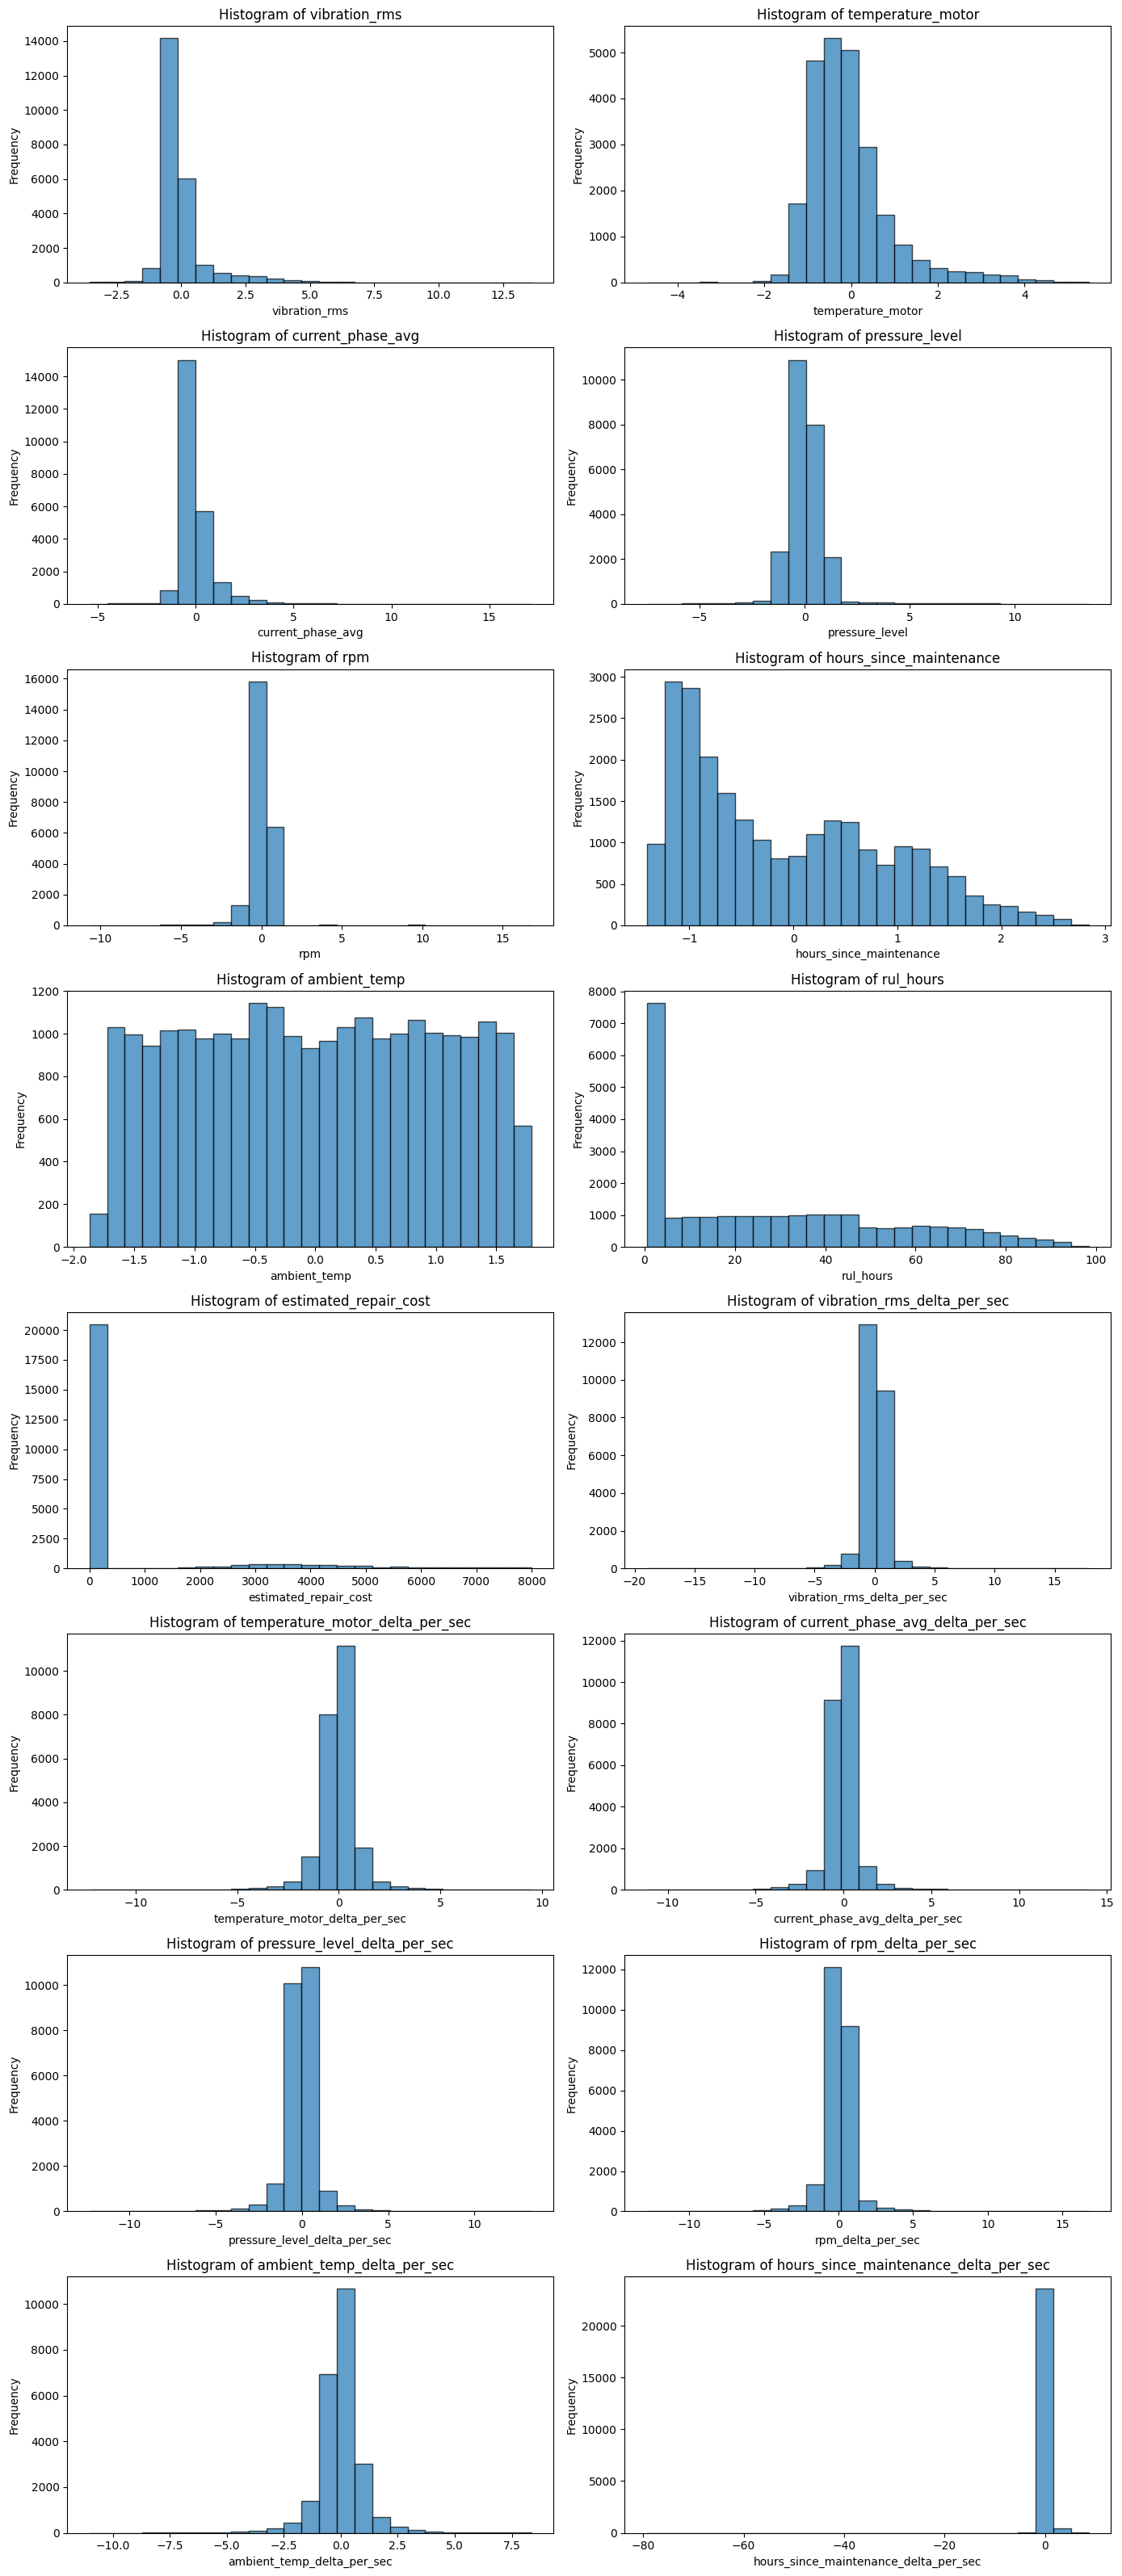

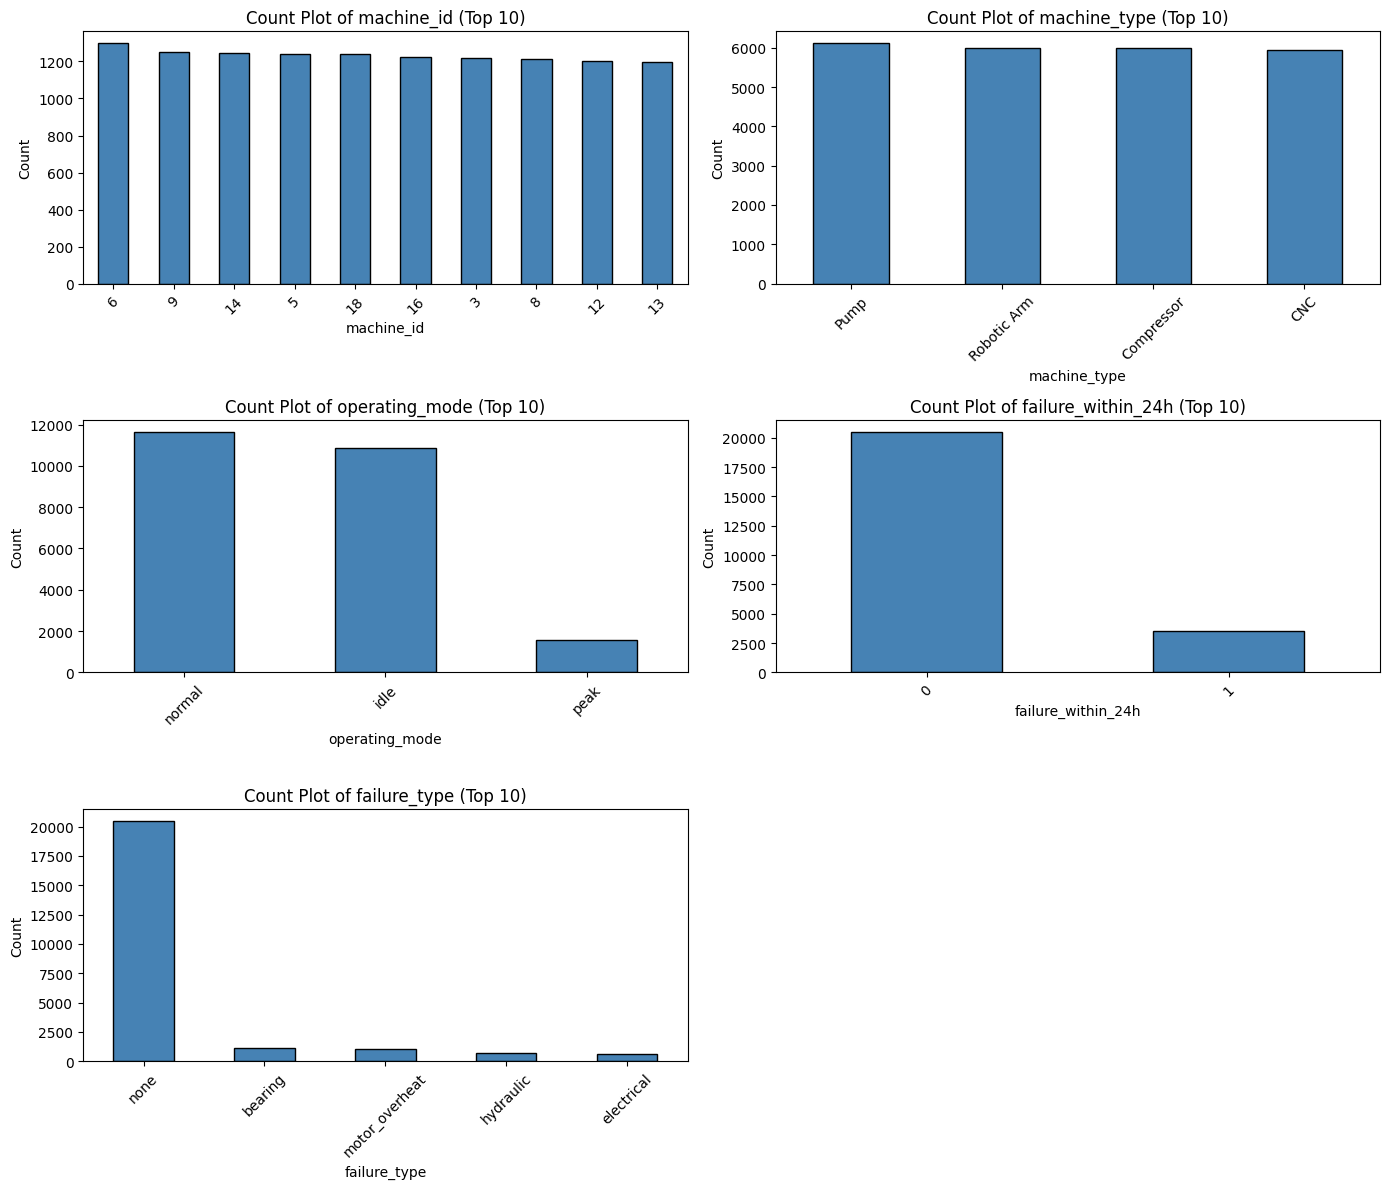

In [60]:
# Plot histograms for numeric columns
import matplotlib.pyplot as plt

target_columns = ['rul_hours', 'failure_within_24h', 'estimated_repair_cost', 'failure_type']
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [col for col in numeric_cols if col not in ['timestamp_seconds']]
numeric_features = [col for col in numeric_cols if col not in target_columns]

num_cols = len(numeric_cols)
cols = 2
rows = (num_cols + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=25, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide extra subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Plot count plots for categorical columns (simplified)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    num_cat = len(categorical_cols)
    cols = 2
    rows = (num_cat + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(categorical_cols):
        # Limit categories shown to avoid slow rendering
        counts = df[col].value_counts().head(10)  # Top 10 categories only
        counts.plot(kind='bar', ax=axes[i], edgecolor='black', color='steelblue')
        axes[i].set_title(f'Count Plot of {col} (Top 10)')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide extra subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


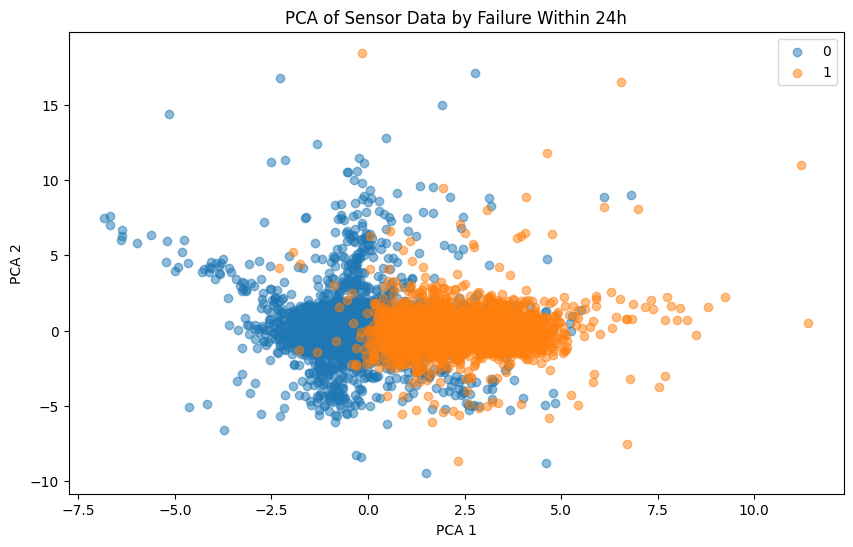

In [61]:
# Plot PCA to visualize the data
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df[columns_to_scale])
df['pca1'] = pca_result[:, 0]
df['pca2'] = pca_result[:, 1]
plt.figure(figsize=(10, 6))
for op in df['failure_within_24h'].unique():
    subset = df[df['failure_within_24h'] == op]
    plt.scatter(subset['pca1'], subset['pca2'], label=op, alpha=0.5)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA of Sensor Data by Failure Within 24h')
plt.legend()
plt.show()

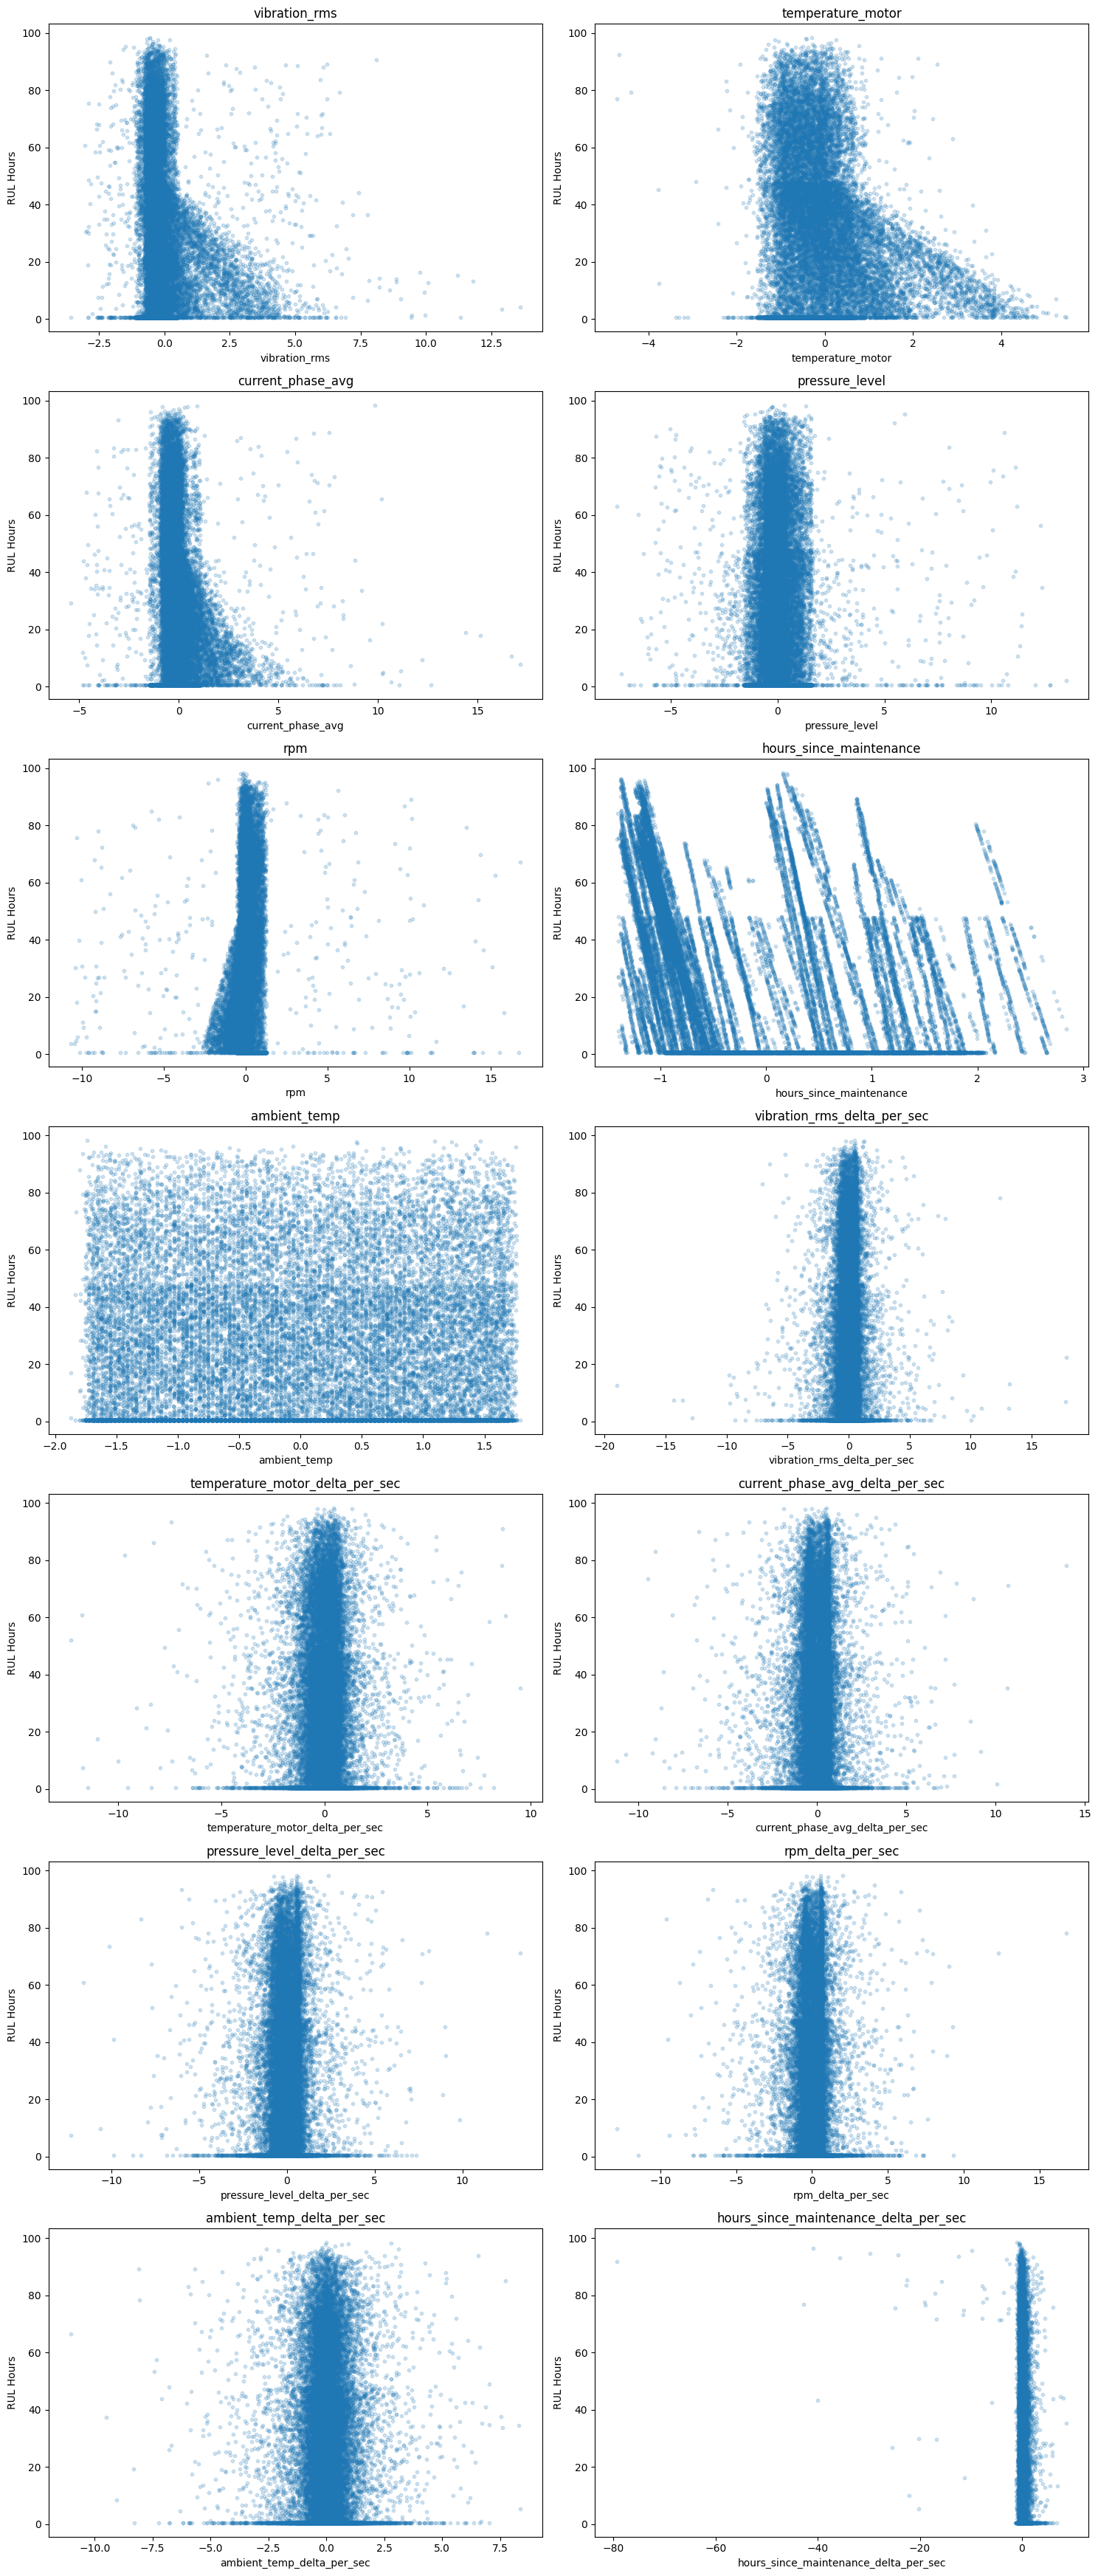

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt


# For all numeric columns, plot scatter plots against rul_hours as subplots
num_cols = 2
num_rows = (len(numeric_features) + num_cols - 1) // num_cols
plt.figure(figsize=(15, num_rows * 5))

for i, col in enumerate(numeric_features):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.scatter(
        df[col],
        df['rul_hours'],
        alpha=0.2,
        s=10
    )
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('RUL Hours')

plt.tight_layout()
plt.show()


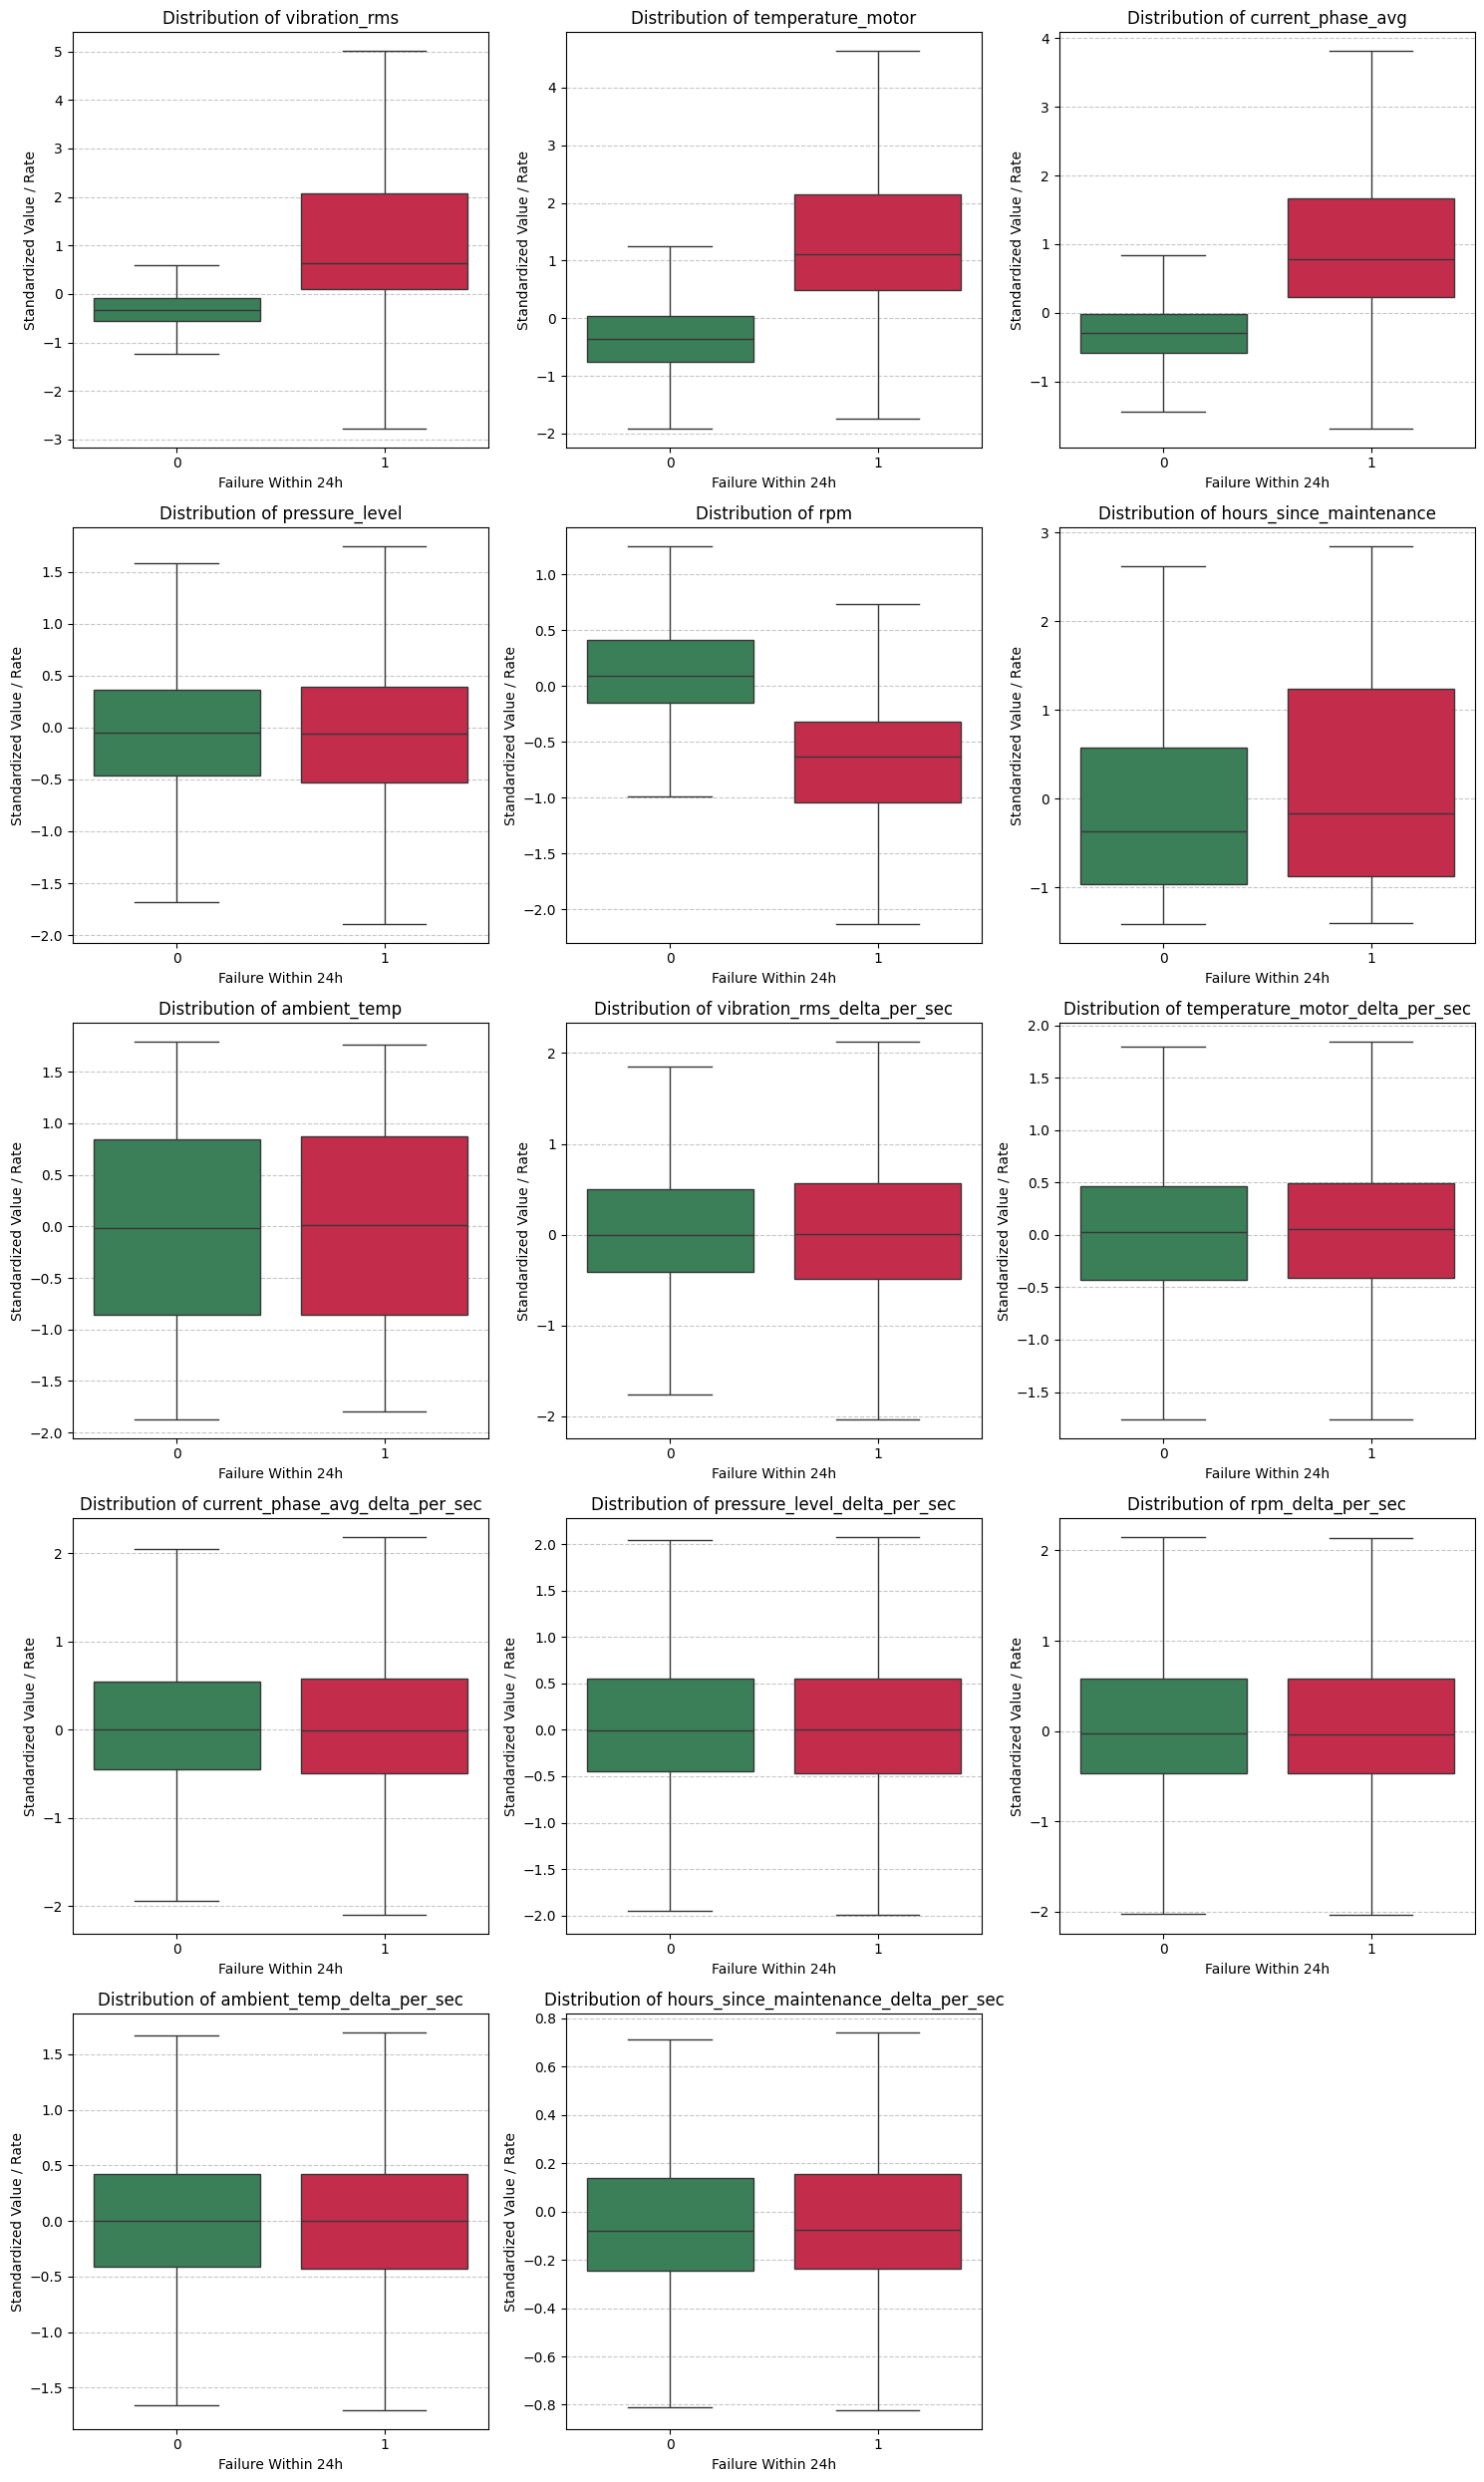

In [63]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

# Simplify to just the binary target for comparison
failure_vals = sorted(df['failure_within_24h'].unique().tolist())
num_cols = 3
num_rows = (len(numeric_features) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))
axes = axes.flatten()

# Simple color palette for Failure (Yes/No)
# Red for failure imminent, Green/Blue for normal
colors = {failure_vals[0]: "seagreen", failure_vals[1]: "crimson"} 

for i, col in enumerate(numeric_features):
    ax = axes[i]
    
    # Create the boxplot
    # showfliers=False is good here to see the interquartile range clearly
    sns.boxplot(
        x='failure_within_24h', 
        y=col, 
        data=df, 
        ax=ax, 
        palette=colors,
        showfliers=False,
        hue='failure_within_24h',
        legend=False
    )
    
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Failure Within 24h')
    ax.set_ylabel('Standardized Value / Rate')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Clean up empty subplots
for j in range(len(numeric_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [64]:
import pandas as pd
import numpy as np
from scipy import stats

def get_binary_relation_metrics(df, numeric_features, target='failure_within_24h', alpha=0.05):
    results = []
    
    # Calculate Bonferroni factor
    num_tests = len(numeric_features)
    bonferroni_alpha = alpha / num_tests if num_tests > 0 else alpha
    
        
    for col in numeric_features:
        # Clean data for this pair
        data = df[[col, target]].dropna()
        
        # Ensure we have both classes to compare
        if data[target].nunique() < 2:
            continue
        
        group0 = data[data[target] == 0][col]
        group1 = data[data[target] == 1][col]
                    
        # Mann-Whitney U Test (Non-parametric difference test)
        u_stat, u_p = stats.mannwhitneyu(group0, group1, alternative='two-sided')
        
        # Calculate Group Means for physical context
        mean_0 = group0.mean()
        mean_1 = group1.mean()
        mean_diff_pct = ((mean_1 - mean_0) / mean_0 * 100) if mean_0 != 0 else 0

        results.append({
            'Feature': col,
            'U_stat': round(u_stat, 3),
            'MW_U_p_val': u_p,
            'Significant': u_p < alpha,
            'Bonferroni_Sig': u_p < bonferroni_alpha,
            'Mean_No_Fail': round(mean_0, 2),
            'Mean_Fail': round(mean_1, 2),
            'Diff_Pct': round(mean_diff_pct, 1),
            'Samples': len(data)
        })

    return pd.DataFrame(results)

# Run the tests
binary_relation_df = get_binary_relation_metrics(df, numeric_features)

binary_relation_df = binary_relation_df.sort_values(
    by=['MW_U_p_val'], 
    ascending=[True]
)

binary_relation_df['MW_U_p_val'] = binary_relation_df['MW_U_p_val'].apply(lambda x: f"{x:.2e}")
binary_relation_df['U_stat'] = binary_relation_df['U_stat'].apply(lambda x: f"{x:,.1f}")

print(binary_relation_df.to_string(index=False))

                              Feature       U_stat MW_U_p_val  Significant  Bonferroni_Sig  Mean_No_Fail  Mean_Fail  Diff_Pct  Samples
                        vibration_rms  8,766,084.0   0.00e+00         True            True         -0.24       1.18    -593.9    24042
                    temperature_motor  6,274,858.0   0.00e+00         True            True         -0.31       1.38    -546.1    24042
                    current_phase_avg  8,690,585.0   0.00e+00         True            True         -0.24       1.08    -544.1    24042
                                  rpm 65,407,211.0   0.00e+00         True            True          0.16      -0.73    -549.8    24042
              hours_since_maintenance 31,407,228.0   7.27e-40         True            True         -0.13       0.17    -233.2    24042
      temperature_motor_delta_per_sec 35,605,079.0   2.57e-02         True           False         -0.02       0.03    -274.4    24042
hours_since_maintenance_delta_per_sec 35,875,772.0   1.

In [ ]:
import pandas as pd
from scipy import stats

def get_numeric_relation_metrics(df, numeric_features, target='rul_hours', alpha=0.05):
    results = []

    num_tests = len(numeric_features)
    bonferroni_alpha = alpha / num_tests if num_tests > 0 else alpha
    
        
    for col in numeric_features:
        data = df[[col, target]].dropna()
        
        if len(data) < 8:
            continue
            
        x = data[col]
        y = data[target]
        
        # 1. Normality Test
        if len(x) > 5000:
            _, p_norm = stats.normaltest(x)
        else:
            _, p_norm = stats.shapiro(x)
        
        # 2. Outliers
        if x.std() > 0:
            z_scores = stats.zscore(x)
            outlier_pct = (sum(abs(z_scores) > 3) / len(x)) * 100
        else:
            outlier_pct = 0.0

        # 3. Correlations & P-Values
        s_rho, p_val_s = stats.spearmanr(x, y)

        results.append({
            'Feature': col,
            'Spearman_rho': round(s_rho, 3),
            'S_p_val': p_val_s,
            'Significant': p_val_s < alpha,
            'Bonferroni_Significant': p_val_s < bonferroni_alpha,
            'Is_Normal': p_norm > alpha,
            'Outlier_Pct': round(outlier_pct, 2),
            'Samples': len(x)
        })

    return pd.DataFrame(results)

# Run the updated tests
numeric_relation_df = get_numeric_relation_metrics(df, numeric_features)

numeric_relation_df = numeric_relation_df.sort_values(by=['S_p_val'], ascending=[True])

numeric_relation_df['S_p_val'] = numeric_relation_df['S_p_val'].apply(lambda x: f"{x:.2e}")

print(numeric_relation_df.to_string(index=False))

                              Feature  Spearman_rho   S_p_val  Significant  Bonferroni_Significant  Is_Normal  Outlier_Pct  Samples
              hours_since_maintenance        -0.421  0.00e+00         True                    True      False         0.00    24042
                                 pca1        -0.153 2.73e-125         True                    True      False         1.58    24042
                    current_phase_avg        -0.067  4.36e-25         True                    True      False         2.07    24042
                                  rpm         0.065  8.45e-24         True                    True      False         1.16    24042
                    temperature_motor        -0.053  1.82e-16         True                    True      False         2.41    24042
                        vibration_rms        -0.052  4.02e-16         True                    True      False         2.84    24042
         pressure_level_delta_per_sec         0.012  5.47e-02        False  

## Data Modeling and Prediction

**Approach:**
- Developed XGBoost classification model to predict binary failure within 24 hours
- Train/test split: 80/20 (19,233 training records, 4,809 test records)
- Class imbalance handled with scale_pos_weight parameter (5.8:1 ratio)

**Model Configuration:**
- Algorithm: XGBoost Classifier
- Parameters: 100 estimators, max_depth=5, learning_rate=0.1, subsample=0.8
- Evaluation metrics: Precision, Recall, F1-score, ROC-AUC, Confusion Matrix, ROC Curve

**Feature Importance Analysis:**
- Ranked features by XGBoost importance scores
- Identified most predictive sensors for failure detection

Features used: ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'vibration_rms_delta_per_sec', 'temperature_motor_delta_per_sec', 'current_phase_avg_delta_per_sec', 'pressure_level_delta_per_sec', 'rpm_delta_per_sec', 'ambient_temp_delta_per_sec', 'hours_since_maintenance_delta_per_sec']
Training set shape: (19772, 14)
Test set shape: (4270, 14)

Target distribution (training):
failure_within_24h
0    16420
1     3352
Name: count, dtype: int64

Target distribution (test):
failure_within_24h
0    4062
1     208
Name: count, dtype: int64

TRAINING SET PERFORMANCE
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     16420
           1       0.94      0.93      0.94      3352

    accuracy                           0.98     19772
   macro avg       0.96      0.96      0.96     19772
weighted avg       0.98      0.98      0.98     19772


TEST SET PERFORMANCE
    

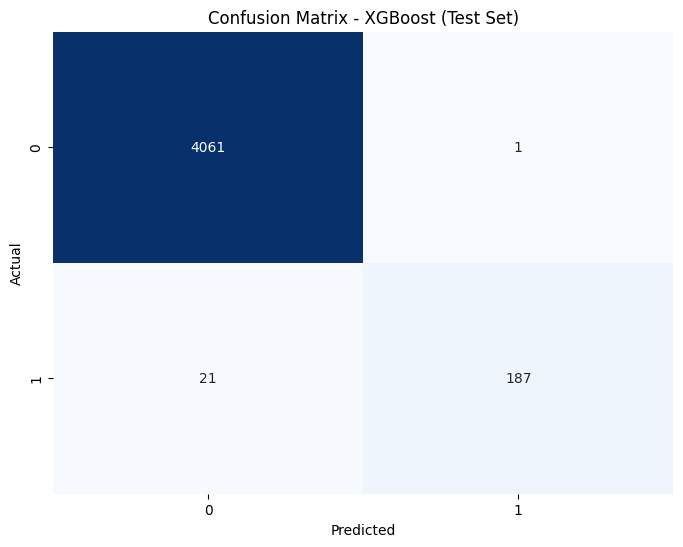


Top 5 Most Important Features:
             Feature  Importance
1  temperature_motor    0.272945
4                rpm    0.217362
0      vibration_rms    0.141416
3     pressure_level    0.098468
2  current_phase_avg    0.090259


In [ ]:
# XGBoost Classification Model for Failure Prediction
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare features and target for both train and test sets
# Exclude non-numeric and non-predictive columns
exclude_cols = ['timestamp', 'timestamp_seconds', 'machine_id', 'machine_type', 'operating_mode', 'failure_type', 'rul_hours', 'pca1', 'pca2', 'estimated_repair_cost']
feature_cols = [col for col in numeric_features if col not in exclude_cols]
feature_cols = [col for col in feature_cols if col in train.columns]

X_train = train[feature_cols]
y_train = train['failure_within_24h']

X_test = test[feature_cols]
y_test = test['failure_within_24h']

print(f'Features used: {feature_cols}')
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')
print(f'\nTarget distribution (training):')
print(y_train.value_counts())
print(f'\nTarget distribution (test):')
print(y_test.value_counts())

# Train XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
 )

xgb_model.fit(X_train, y_train)

# Make predictions
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)
y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate model
print('\n' + '='*60)
print('TRAINING SET PERFORMANCE')
print('='*60)
print(classification_report(y_train, y_train_pred))

print('\n' + '='*60)
print('TEST SET PERFORMANCE')
print('='*60)
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - XGBoost (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nTop 5 Most Important Features:')
print(feature_importance.head())


## Results Analysis

**Model Performance:**
- Test Accuracy: 96%
- ROC-AUC: 0.9934
- Precision (failures): 81% - When model predicts failure, it is correct 81% of the time
- Recall (failures): 96% - Model catches 96% of actual failures (very low false negatives)

**Hypothesis Assessment:**
Our hypothesis was: "If sensor data varies significantly from the standard operating range, then the RUL will decrease and the machine will fail within 24 hours."

*Result:* **SUPPORTED** - The model demonstrates that sensor anomalies (elevated temperature, vibration, current) are strong predictors of failure within 24 hours, achieving 96% accuracy with high recall.

**Key Insights:**
1. Temperature and vibration are the strongest predictive features
2. The model prioritizes recall (catching failures) over precision (minimizing false alarms) - appropriate for maintenance systems
3. Operating mode influences failure patterns - different operational states show different sensor degradation signatures